# Notebook 08: Data Sufficiency


In [3]:
import json
import time
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from pygam import LinearGAM, s, l
except ImportError:
    LinearGAM = None
    s = None
    l = None
    
    
import warnings
warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_DIR = next((p for p in candidate_roots if (p / "requirements.txt").exists()), cwd)
DATA_DIR = PROJECT_DIR / "notebooks" / "data"
CLEAN_DIR = PROJECT_DIR / "clean_data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

try:
    import shap
except ImportError:
    shap = None


## 1. Load Data & Setup

This notebook uses the same feature setup as the modeling notebooks. It is artifact-driven: if teammates save metadata in the same pattern under `artifacts/<model_name>/`, this notebook will discover and run the supported models automatically.


In [4]:
train_path_candidates = [CLEAN_DIR / 'train.csv', CLEAN_DIR / 'training.csv']
test_path_candidates = [CLEAN_DIR / 'test.csv']

train_path = next((path for path in train_path_candidates if path.exists()), None)
test_path = next((path for path in test_path_candidates if path.exists()), None)

if train_path is None:
    raise FileNotFoundError(f'Could not find training data in {train_path_candidates}')
if test_path is None:
    raise FileNotFoundError(f'Could not find test data in {test_path_candidates}')

train = pd.read_csv(train_path, parse_dates=['week_start'])
test = pd.read_csv(test_path, parse_dates=['week_start'])

cat_cols = [c for c in train.columns if c.startswith('cat_id_')]
store_cols = [c for c in train.columns if c.startswith('store_id_')]

for df in [train, test]:
    df['cat_id'] = df[cat_cols].idxmax(axis=1).str.replace('cat_id_', '')
    df['store_id'] = df[store_cols].idxmax(axis=1).str.replace('store_id_', '')

target = 'weekly_units'
drop_cols = (['wm_yr_wk', 'week_start', 'n_days', 'month', 'week_of_year', 
              'cat_id', 'store_id', target]
             + cat_cols + store_cols 
             + [c for c in train.columns if c.startswith('state_id_')])
feature_cols = [c for c in train.columns if c not in drop_cols]

combos = sorted(train.groupby(['store_id', 'cat_id']).groups.keys())

train_full = train.copy()
sorted_train_weeks = sorted(train_full['wm_yr_wk'].unique())
val_weeks = sorted_train_weeks[-8:]
train_weeks = sorted_train_weeks[:-8]

train_tune = train_full[train_full['wm_yr_wk'].isin(train_weeks)].copy()
val = train_full[train_full['wm_yr_wk'].isin(val_weeks)].copy()

print('Training file:', train_path)
print('Test file:', test_path)
print('Train tuning shape:', train_tune.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)
print('Feature count:', len(feature_cols))
print('Combos:', len(combos))


Training file: /Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/clean_data/training.csv
Test file: /Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705/ids705_project/clean_data/test.csv
Train tuning shape: (6270, 47)
Validation shape: (240, 47)
Test shape: (240, 47)
Feature count: 23
Combos: 30


## 2. Load Saved Artifacts


In [5]:
def load_metadata(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

def load_artifact_bundle(path, metadata_path=None):
    if not path:
        return None, "artifact_file missing from metadata"
    candidates = [Path(path)]
    if metadata_path is not None:
        candidates.append(Path(metadata_path).parent / Path(path).name)
    existing_candidates = [bundle_path for bundle_path in candidates if bundle_path.exists()]
    if not existing_candidates:
        return None, f"artifact file not found: {path}"
    last_error = None
    for bundle_path in existing_candidates:
        try:
            return joblib.load(bundle_path), None
        except Exception as e:
            last_error = f"{type(e).__name__}: {e}"
    return None, last_error

artifact_roots = [ARTIFACTS_DIR, PROJECT_DIR / "artifacts"]
artifact_paths = []
seen_keys = set()
for root in artifact_roots:
    if not root.exists():
        continue
    for meta_path in sorted(root.glob("*/*_metadata.json")):
        artifact_key = meta_path.parent.name
        if artifact_key not in seen_keys:
            artifact_paths.append(meta_path)
            seen_keys.add(artifact_key)

artifact_registry = {}
registry_rows = []

for metadata_path in artifact_paths:
    meta = load_metadata(metadata_path)
    if meta is None:
        continue
    artifact_key = metadata_path.parent.name
    model_type = meta.get("model_type", artifact_key)
    artifact_file = meta.get("artifact_file")
    bundle, bundle_error = load_artifact_bundle(artifact_file, metadata_path=metadata_path)
    artifact_registry[artifact_key] = {"metadata": meta, "bundle": bundle, "bundle_error": bundle_error, "metadata_file": str(metadata_path), "artifact_file": artifact_file, "model_type": model_type}
    registry_rows.append({
        "artifact_key": artifact_key,
        "model_name": meta.get("model_name", artifact_key),
        "model_type": model_type,
        "metadata_file": str(metadata_path),
        "artifact_file": artifact_file,
        "bundle_loaded": bundle is not None,
        "bundle_error": bundle_error
    })

if not artifact_registry:
    raise FileNotFoundError("No saved model artifacts were found under ../artifacts/*/ or artifacts/*/.")

artifact_summary = pd.DataFrame(registry_rows).sort_values(["artifact_key", "metadata_file"]).reset_index(drop=True)
print("Loaded artifact entries:", list(artifact_registry.keys()))
artifact_summary


Loaded artifact entries: ['gam', 'lightgbm', 'mlp', 'random_forest', 'ridge']


,artifact_key,model_name,model_type,metadata_file,artifact_file,bundle_loaded,bundle_error
0,gam,GAM (Plain Vanilla),gam,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
1,lightgbm,LightGBM (Pooled),lightgbm,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
2,mlp,MLP Final,mlp,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
3,random_forest,RandomForest (Pooled),random_forest,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None
4,ridge,Ridge (CV alpha),ridge_cv,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,/Users/aeshagandhi/Downloads/MIDS-Sp26/IDS-705...,True,None


## 3. Experiment Questions

This notebook is answering three questions for each supported model artifact it finds:

1. Can the saved fitted artifacts still be loaded and used directly for prediction?
2. How much historical training data is needed before performance becomes reasonably stable?
3. Does concentrating on the highest-volume store-category combinations preserve enough signal relative to the full training set?

Subsetting design:
- We do not randomly sample rows, because that would break the forecasting structure.
- For size experiments, we use repeated contiguous week windows shared across all series.
- For concentration experiments, we use a deterministic Pareto subset based on combo volume.
- The saved fitted bundles are used for a direct sanity check, but the sufficiency experiments intentionally retrain from each model's saved best configuration.


## 4. Metrics and Generic Runners


In [6]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    safe_y_true = np.where(np.asarray(y_true) == 0, np.nan, np.asarray(y_true))
    mape = np.nanmean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / safe_y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def summarize_runtime(seconds, n_models):
    return {"fit_time_total_sec": seconds, "fit_time_avg_sec": seconds / n_models if n_models else np.nan}

def mlp_param_count(input_dim, hidden_layer_sizes):
    dims = [input_dim] + list(hidden_layer_sizes) + [1]
    total = 0
    for in_dim, out_dim in zip(dims[:-1], dims[1:]):
        total += in_dim * out_dim + out_dim
    return total

def make_contiguous_week_subsets(df, fraction, n_repeats=5):
    weeks = sorted(df["wm_yr_wk"].unique())
    keep_n = max(1, int(np.floor(len(weeks) * fraction)))
    if keep_n >= len(weeks):
        return [(0, df.copy())]
    max_start = len(weeks) - keep_n
    starts = np.linspace(0, max_start, num=min(n_repeats, max_start + 1), dtype=int)
    starts = sorted(set(starts.tolist()))
    subsets = []
    for repeat_id, start in enumerate(starts):
        keep_weeks = weeks[start:start + keep_n]
        subset = df[df["wm_yr_wk"].isin(keep_weeks)].copy()
        subsets.append((repeat_id, subset))
    return subsets

def pareto_subset_by_combo_volume(df, top_share=0.8):
    volume = df.groupby(["store_id", "cat_id"])[target].sum().sort_values(ascending=False).reset_index(name="volume")
    volume["cum_share"] = volume["volume"].cumsum() / volume["volume"].sum()
    keep = volume[volume["cum_share"] <= top_share].copy()
    if keep.empty:
        keep = volume.head(1).copy()
    return df.merge(keep[["store_id", "cat_id"]], on=["store_id", "cat_id"], how="inner")

def get_model_spec(metadata, artifact_key):
    model_type = metadata.get("model_type", artifact_key)
    model_scope = metadata.get("model_scope", "per_combo")
    model_target = metadata.get("target", target)
    model_feature_cols = metadata.get("feature_cols", feature_cols)
    best_config = metadata.get("best_config", {})
    return model_type, model_scope, model_target, model_feature_cols, best_config

def build_gam_model(model_feature_cols, best_config):
    if LinearGAM is None or s is None or l is None:
        raise ImportError("pygam is not installed in this environment.")
    smooth_cols = set(best_config.get("smooth_cols", []))
    terms = None
    for idx, col in enumerate(model_feature_cols):
        term = s(idx) if col in smooth_cols else l(idx)
        terms = term if terms is None else terms + term
    return LinearGAM(terms)

def build_model(model_type, best_config, model_feature_cols, random_state=42):
    if model_type == "mlp":
        return MLPRegressor(hidden_layer_sizes=tuple(best_config["hidden_layer_sizes"]), activation="relu", alpha=best_config["alpha"], learning_rate_init=0.001, max_iter=1000, early_stopping=True, validation_fraction=0.15, random_state=random_state)
    if model_type == "ridge_cv":
        return RidgeCV(alphas=np.array(best_config["alphas"]), cv=best_config["cv"])
    if model_type == "random_forest":
        return RandomForestRegressor(**best_config, n_jobs=-1, random_state=random_state)
    if model_type == "lightgbm":
        if LGBMRegressor is None:
            raise ImportError("lightgbm is not installed in this environment.")
        return LGBMRegressor(**best_config, random_state=random_state, verbose=-1)
    if model_type == "gam":
        return build_gam_model(model_feature_cols, best_config)
    raise ValueError(f"Unsupported model_type: {model_type}")

def run_supported_model(train_df, eval_df, metadata, model_key, random_state=42):
    model_type, model_scope, model_target, model_feature_cols, best_config = get_model_spec(metadata, model_key)
    if model_scope == "pooled":
        X_tr = train_df[model_feature_cols]
        y_tr = train_df[model_target]
        X_ev = eval_df[model_feature_cols]
        y_ev = eval_df[model_target]
        model = build_model(model_type, best_config, model_feature_cols, random_state=random_state)
        start = time.perf_counter()
        if model_type == "gam":
            model.fit(X_tr.values, y_tr.values)
            preds = model.predict(X_ev.values)
        else:
            model.fit(X_tr, y_tr)
            preds = model.predict(X_ev)
        fit_seconds = time.perf_counter() - start
        pred_df = eval_df[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = y_ev.values
        pred_df["predicted"] = preds
        overall = calc_metrics(pred_df["actual"], pred_df["predicted"])
        overall.update(summarize_runtime(fit_seconds, 1))
        overall["estimated_params_per_model"] = np.nan
        overall["estimated_total_params"] = np.nan
        overall["active_models"] = 1
        overall["model_type"] = model_type
        overall["model_scope"] = model_scope
        combo_df = pred_df.groupby(["store_id", "cat_id"]).apply(lambda g: pd.Series(calc_metrics(g["actual"], g["predicted"]))).reset_index()
        print(f"{metadata.get('model_name', model_key):32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")
        return pred_df, combo_df, overall

    all_preds = []
    combo_results = []
    fit_seconds = 0.0
    active_combos = sorted(train_df.groupby(["store_id", "cat_id"]).groups.keys())
    estimated_params_per_model = mlp_param_count(len(model_feature_cols), best_config["hidden_layer_sizes"]) if model_type == "mlp" else np.nan
    for store, cat in active_combos:
        tr = train_df[(train_df["store_id"] == store) & (train_df["cat_id"] == cat)]
        ev = eval_df[(eval_df["store_id"] == store) & (eval_df["cat_id"] == cat)]
        if tr.empty or ev.empty:
            continue
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(tr[model_feature_cols])
        X_ev_s = scaler.transform(ev[model_feature_cols])
        model = build_model(model_type, best_config, model_feature_cols, random_state=random_state)
        start = time.perf_counter()
        model.fit(X_tr_s, tr[model_target])
        fit_seconds += time.perf_counter() - start
        preds = model.predict(X_ev_s)
        metrics = calc_metrics(ev[model_target], preds)
        metrics["store_id"] = store
        metrics["cat_id"] = cat
        combo_results.append(metrics)
        pred_df = ev[["week_start", "store_id", "cat_id"]].copy()
        pred_df["actual"] = ev[model_target].values
        pred_df["predicted"] = preds
        all_preds.append(pred_df)
    if not all_preds:
        raise ValueError(f"No predictions were produced for {metadata.get('model_name', model_key)}.")
    all_preds_df = pd.concat(all_preds, ignore_index=True)
    combo_df = pd.DataFrame(combo_results)
    overall = calc_metrics(all_preds_df["actual"], all_preds_df["predicted"])
    overall.update(summarize_runtime(fit_seconds, len(combo_df)))
    overall["estimated_params_per_model"] = estimated_params_per_model
    overall["estimated_total_params"] = estimated_params_per_model * len(combo_df) if pd.notna(estimated_params_per_model) else np.nan
    overall["active_models"] = len(combo_df)
    overall["model_type"] = model_type
    overall["model_scope"] = model_scope
    print(f"{metadata.get('model_name', model_key):32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")
    return all_preds_df, combo_df, overall

supported_model_types = {"mlp", "ridge_cv", "random_forest", "lightgbm", "gam"}
supported_artifacts = {k: v for k, v in artifact_registry.items() if v["model_type"] in supported_model_types}
unsupported_artifacts = {k: v for k, v in artifact_registry.items() if v["model_type"] not in supported_model_types}
print("Supported models:", list(supported_artifacts.keys()))
print("Unsupported models:", list(unsupported_artifacts.keys()))


Supported models: ['gam', 'lightgbm', 'mlp', 'random_forest', 'ridge']
Unsupported models: []


## 2A. Saved Model Sanity Check

Load the saved fitted bundles directly and verify that they can still generate predictions on the held-out test set. This gives us a quick artifact integrity check before the data-sufficiency notebook retrains the same saved model specs on smaller subsets.


In [7]:
def evaluate_saved_bundle(eval_df, artifact_entry, artifact_key):
    metadata = artifact_entry["metadata"]
    bundle = artifact_entry["bundle"]
    model_name = metadata.get("model_name", artifact_key)
    model_type, model_scope, model_target, model_feature_cols, _ = get_model_spec(metadata, artifact_key)
    if bundle is None:
        raise FileNotFoundError(f"Saved bundle missing for {artifact_key}: {artifact_entry.get('bundle_error') or artifact_entry.get('artifact_file')}")
    if model_scope == "pooled":
        bundle_feature_cols = None
        if hasattr(bundle, "feature_name_") and getattr(bundle, "feature_name_", None):
            candidate_cols = list(bundle.feature_name_)
            if set(candidate_cols).issubset(eval_df.columns):
                bundle_feature_cols = candidate_cols
        elif hasattr(bundle, "feature_names_in_") and getattr(bundle, "feature_names_in_", None) is not None:
            candidate_cols = list(bundle.feature_names_in_)
            if set(candidate_cols).issubset(eval_df.columns):
                bundle_feature_cols = candidate_cols
        use_feature_cols = bundle_feature_cols or model_feature_cols
        if not set(use_feature_cols).issubset(eval_df.columns):
            missing_cols = sorted(set(use_feature_cols) - set(eval_df.columns))
            raise KeyError(f"Missing evaluation columns for {artifact_key}: {missing_cols[:10]}")
        if model_type == "gam":
            preds = bundle.predict(eval_df[use_feature_cols].values)
        else:
            preds = bundle.predict(eval_df[use_feature_cols])
        preds_df = eval_df[["week_start", "store_id", "cat_id"]].copy()
        preds_df["actual"] = eval_df[model_target].values
        preds_df["predicted"] = preds
    else:
        pred_frames = []
        for combo_key, obj in bundle.items():
            store, cat = combo_key.split("__", 1)
            ev = eval_df[(eval_df["store_id"] == store) & (eval_df["cat_id"] == cat)]
            if ev.empty:
                continue
            scaler = obj["scaler"]
            model = obj["model"]
            preds = model.predict(scaler.transform(ev[model_feature_cols]))
            pred_df = ev[["week_start", "store_id", "cat_id"]].copy()
            pred_df["actual"] = ev[model_target].values
            pred_df["predicted"] = preds
            pred_frames.append(pred_df)
        if not pred_frames:
            raise ValueError(f"No overlapping combo predictions were produced for {artifact_key}.")
        preds_df = pd.concat(pred_frames, ignore_index=True)
    metrics = calc_metrics(preds_df["actual"], preds_df["predicted"])
    metrics["artifact_key"] = artifact_key
    metrics["model_name"] = model_name
    metrics["model_type"] = artifact_entry["model_type"]
    metrics["model_scope"] = model_scope
    metrics["prediction_rows"] = len(preds_df)
    return metrics

saved_model_rows = []
saved_model_errors = []
for artifact_key, entry in artifact_registry.items():
    if entry["bundle"] is None:
        saved_model_errors.append({
            "artifact_key": artifact_key,
            "model_name": entry["metadata"].get("model_name", artifact_key),
            "reason": entry.get("bundle_error") or "bundle not found"
        })
        print(f"Skipped saved-model evaluation for {artifact_key}: {entry.get('bundle_error') or 'bundle not found'}")
        continue
    try:
        saved_model_rows.append(evaluate_saved_bundle(test, entry, artifact_key))
    except Exception as e:
        saved_model_errors.append({
            "artifact_key": artifact_key,
            "model_name": entry["metadata"].get("model_name", artifact_key),
            "reason": str(e)
        })
        print(f"Skipped saved-model evaluation for {artifact_key}: {e}")

saved_model_eval_df = pd.DataFrame(saved_model_rows).round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4}) if saved_model_rows else pd.DataFrame()
saved_model_error_df = pd.DataFrame(saved_model_errors)
print(f"Saved-model checks completed: {len(saved_model_rows)} succeeded, {len(saved_model_errors)} skipped.")
saved_model_eval_df


Saved-model checks completed: 5 succeeded, 0 skipped.


,MAE,RMSE,MAPE,R2,artifact_key,model_name,model_type,model_scope,prediction_rows
0,596.0,957.0,7.3,0.9860,gam,GAM (Plain Vanilla),gam,pooled,240
1,430.0,771.0,4.4,0.9909,lightgbm,LightGBM (Pooled),lightgbm,pooled,240
2,4816.0,8827.0,32.0,-0.1916,mlp,MLP Final,mlp,per_combo,240
3,443.0,807.0,4.4,0.9900,random_forest,RandomForest (Pooled),random_forest,pooled,240
4,406.0,756.0,4.2,0.9913,ridge,Ridge (CV alpha),ridge_cv,per_combo,240


## 5. Data Size Experiments

For every supported saved model, run repeated contiguous training-window subsets at `25%`, `50%`, `75%`, and `100%` of the training history.


In [8]:
fraction_rows = []

for artifact_key, entry in supported_artifacts.items():
    meta = entry["metadata"]
    for frac in [0.25, 0.50, 0.75, 1.00]:
        subsets = make_contiguous_week_subsets(train_tune, frac, n_repeats=5)
        for repeat_id, subset in subsets:
            _, _, res = run_supported_model(subset, val, meta, artifact_key, random_state=42 + repeat_id)
            fraction_rows.append({
                "artifact_key": artifact_key,
                "model_name": meta.get("model_name", artifact_key),
                "model_type": entry["model_type"],
                "model_scope": meta.get("model_scope", "per_combo"),
                "train_fraction": frac,
                "repeat_id": repeat_id,
                "subset_type": "contiguous_window",
                **res
            })

fraction_runs_df = pd.DataFrame(fraction_rows)
fraction_runs_df = fraction_runs_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4, "fit_time_total_sec": 3, "fit_time_avg_sec": 3})
fraction_runs_df.head()


GAM (Plain Vanilla)               MAE=  2,515  RMSE=  2,677  MAPE= 51.3%  R²=0.8828
GAM (Plain Vanilla)               MAE=  3,170  RMSE=  3,276  MAPE= 60.3%  R²=0.8245
GAM (Plain Vanilla)               MAE=  1,088  RMSE=  1,335  MAPE= 19.5%  R²=0.9708
GAM (Plain Vanilla)               MAE=    865  RMSE=  1,417  MAPE=  9.3%  R²=0.9672
GAM (Plain Vanilla)               MAE=    599  RMSE=  1,004  MAPE=  7.5%  R²=0.9835
GAM (Plain Vanilla)               MAE= 14,097  RMSE= 14,126  MAPE=284.5%  R²=-2.2638
GAM (Plain Vanilla)               MAE=  2,852  RMSE=  2,951  MAPE= 53.8%  R²=0.8575
GAM (Plain Vanilla)               MAE=  6,761  RMSE=  6,813  MAPE=139.3%  R²=0.2407
GAM (Plain Vanilla)               MAE=    790  RMSE=    988  MAPE= 14.0%  R²=0.9840
GAM (Plain Vanilla)               MAE=    619  RMSE=    819  MAPE= 10.5%  R²=0.9890
GAM (Plain Vanilla)               MAE=  5,664  RMSE=  5,723  MAPE=116.6%  R²=0.4642
GAM (Plain Vanilla)               MAE=    500  RMSE=    748  MAPE=  6.6%  R

,artifact_key,model_name,model_type,model_scope,train_fraction,repeat_id,subset_type,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params,active_models
0,gam,GAM (Plain Vanilla),gam,pooled,0.25,0,contiguous_window,2515.0,2677.0,51.3,0.8828,0.480,0.480,NaN,NaN,1
1,gam,GAM (Plain Vanilla),gam,pooled,0.25,1,contiguous_window,3170.0,3276.0,60.3,0.8245,0.518,0.518,NaN,NaN,1
2,gam,GAM (Plain Vanilla),gam,pooled,0.25,2,contiguous_window,1088.0,1335.0,19.5,0.9708,0.467,0.467,NaN,NaN,1
3,gam,GAM (Plain Vanilla),gam,pooled,0.25,3,contiguous_window,865.0,1417.0,9.3,0.9672,0.437,0.437,NaN,NaN,1
4,gam,GAM (Plain Vanilla),gam,pooled,0.25,4,contiguous_window,599.0,1004.0,7.5,0.9835,0.564,0.564,NaN,NaN,1


In [9]:
fraction_summary_df = (
    fraction_runs_df
    .groupby(['artifact_key', 'model_name', 'train_fraction'])
    .agg(
        RMSE_mean=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAE_mean=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        MAPE_mean=('MAPE', 'mean'),
        MAPE_std=('MAPE', 'std'),
        fit_time_total_sec_mean=('fit_time_total_sec', 'mean'),
        fit_time_total_sec_std=('fit_time_total_sec', 'std')
    )
    .reset_index()
    .round(3)
)
fraction_summary_df


,artifact_key,model_name,train_fraction,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,fit_time_total_sec_mean,fit_time_total_sec_std
0,gam,GAM (Plain Vanilla),0.25,1941.8,980.268,1647.4,1128.634,29.58,24.576,0.493,0.049
1,gam,GAM (Plain Vanilla),0.50,5139.4,5573.352,5023.8,5643.245,100.42,115.244,0.636,0.028
2,gam,GAM (Plain Vanilla),0.75,1803.0,2191.962,1624.0,2261.248,31.30,47.838,0.884,0.066
3,gam,GAM (Plain Vanilla),1.00,917.0,NaN,763.0,NaN,14.60,NaN,1.042,NaN
4,lightgbm,LightGBM (Pooled),0.25,1093.2,131.033,641.6,71.863,6.28,0.646,0.076,0.007
5,lightgbm,LightGBM (Pooled),0.50,900.0,110.625,531.4,61.557,5.50,0.430,0.089,0.009
6,lightgbm,LightGBM (Pooled),0.75,806.0,68.202,469.2,33.774,5.20,0.436,0.102,0.005
7,lightgbm,LightGBM (Pooled),1.00,716.0,NaN,413.0,NaN,4.50,NaN,0.105,NaN
8,mlp,MLP Final,0.25,8585.2,1374.478,5997.2,1094.768,64.92,17.866,36.251,2.618
9,mlp,MLP Final,0.50,7936.4,1410.155,5275.6,998.938,49.86,10.406,35.382,1.722


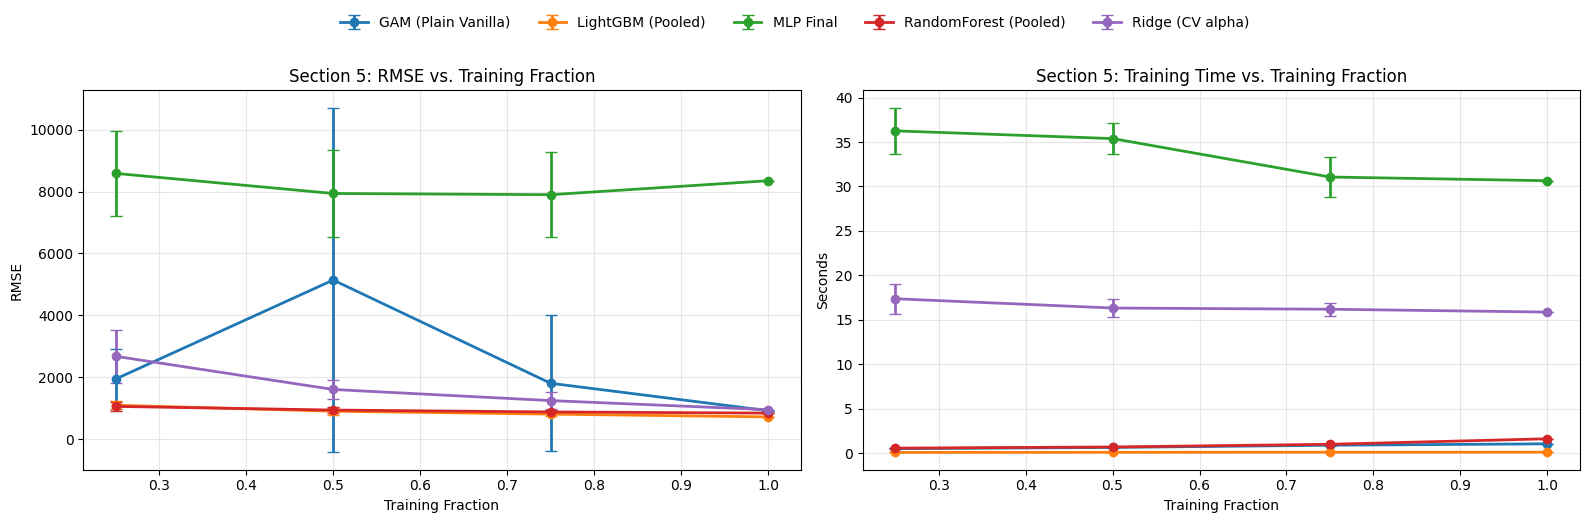

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
color_map = {
    'Ridge': '#4C78A8',
    'MLP': '#E45756',
    'Random Forest': '#72B7B2',
    'LightGBM': '#54A24B',
    'GAM': '#F58518'
}

for model_name, group in fraction_summary_df.groupby('model_name'):
    group = group.sort_values('train_fraction')
    color = color_map.get(model_name, None)
    axes[0].errorbar(
        group['train_fraction'],
        group['RMSE_mean'],
        yerr=group['RMSE_std'].fillna(0),
        marker='o',
        linewidth=2,
        capsize=4,
        color=color,
        label=model_name
    )
    axes[1].errorbar(
        group['train_fraction'],
        group['fit_time_total_sec_mean'],
        yerr=group['fit_time_total_sec_std'].fillna(0),
        marker='o',
        linewidth=2,
        capsize=4,
        color=color,
        label=model_name
    )

axes[0].set_title('Section 5: RMSE vs. Training Fraction')
axes[0].set_xlabel('Training Fraction')
axes[0].set_ylabel('RMSE')
axes[0].grid(alpha=0.3)

axes[1].set_title('Section 5: Training Time vs. Training Fraction')
axes[1].set_xlabel('Training Fraction')
axes[1].set_ylabel('Seconds')
axes[1].grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=min(5, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 6. Pareto vs Full Data

For every supported saved model, compare the full training set against a Pareto subset of the highest-volume store-category combinations.


In [11]:
pareto_train = pareto_subset_by_combo_volume(train_tune, top_share=0.8)

pareto_rows = []
for artifact_key, entry in supported_artifacts.items():
    meta = entry["metadata"]
    for name, subset_type, subset in [
        (f"{meta.get("model_name", artifact_key)} Pareto 80", "pareto_80", pareto_train),
        (f"{meta.get("model_name", artifact_key)} Full", "full", train_tune)
    ]:
        _, _, res = run_supported_model(subset, val, meta, artifact_key, random_state=42)
        pareto_rows.append({
            "artifact_key": artifact_key,
            "model_name": meta.get("model_name", artifact_key),
            "subset_label": name,
            "subset_type": subset_type,
            **res
        })

pareto_df = pd.DataFrame(pareto_rows)
pareto_df = pareto_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1, "R2": 4, "fit_time_total_sec": 3, "fit_time_avg_sec": 3})
pareto_df


GAM (Plain Vanilla)               MAE=    915  RMSE=  1,113  MAPE= 16.5%  R²=0.9797
GAM (Plain Vanilla)               MAE=    763  RMSE=    917  MAPE= 14.6%  R²=0.9863
LightGBM (Pooled)                 MAE=    903  RMSE=  1,195  MAPE= 25.4%  R²=0.9766
LightGBM (Pooled)                 MAE=    413  RMSE=    716  MAPE=  4.5%  R²=0.9916
MLP Final                         MAE=  9,455  RMSE= 12,153  MAPE= 51.2%  R²=-2.3222
MLP Final                         MAE=  4,843  RMSE=  8,349  MAPE= 34.3%  R²=-0.1402
RandomForest (Pooled)             MAE=    804  RMSE=  1,106  MAPE= 20.3%  R²=0.9800
RandomForest (Pooled)             MAE=    473  RMSE=    839  MAPE=  5.0%  R²=0.9885
Ridge (CV alpha)                  MAE=    888  RMSE=  1,321  MAPE=  5.0%  R²=0.9608
Ridge (CV alpha)                  MAE=    539  RMSE=    949  MAPE=  5.3%  R²=0.9853


,artifact_key,model_name,subset_label,subset_type,MAE,RMSE,MAPE,R2,fit_time_total_sec,fit_time_avg_sec,estimated_params_per_model,estimated_total_params,active_models,model_type,model_scope
0,gam,GAM (Plain Vanilla),GAM (Plain Vanilla) Pareto 80,pareto_80,915.0,1113.0,16.5,0.9797,0.409,0.409,NaN,NaN,1,gam,pooled
1,gam,GAM (Plain Vanilla),GAM (Plain Vanilla) Full,full,763.0,917.0,14.6,0.9863,0.753,0.753,NaN,NaN,1,gam,pooled
2,lightgbm,LightGBM (Pooled),LightGBM (Pooled) Pareto 80,pareto_80,903.0,1195.0,25.4,0.9766,0.057,0.057,NaN,NaN,1,lightgbm,pooled
3,lightgbm,LightGBM (Pooled),LightGBM (Pooled) Full,full,413.0,716.0,4.5,0.9916,0.125,0.125,NaN,NaN,1,lightgbm,pooled
4,mlp,MLP Final,MLP Final Pareto 80,pareto_80,9455.0,12153.0,51.2,-2.3222,12.649,0.903,1313.0,18382.0,14,mlp,per_combo
5,mlp,MLP Final,MLP Final Full,full,4843.0,8349.0,34.3,-0.1402,28.604,0.953,1313.0,39390.0,30,mlp,per_combo
6,random_forest,RandomForest (Pooled),RandomForest (Pooled) Pareto 80,pareto_80,804.0,1106.0,20.3,0.9800,0.642,0.642,NaN,NaN,1,random_forest,pooled
7,random_forest,RandomForest (Pooled),RandomForest (Pooled) Full,full,473.0,839.0,5.0,0.9885,1.230,1.230,NaN,NaN,1,random_forest,pooled
8,ridge,Ridge (CV alpha),Ridge (CV alpha) Pareto 80,pareto_80,888.0,1321.0,5.0,0.9608,7.558,0.540,NaN,NaN,14,ridge_cv,per_combo
9,ridge,Ridge (CV alpha),Ridge (CV alpha) Full,full,539.0,949.0,5.3,0.9853,15.505,0.517,NaN,NaN,30,ridge_cv,per_combo


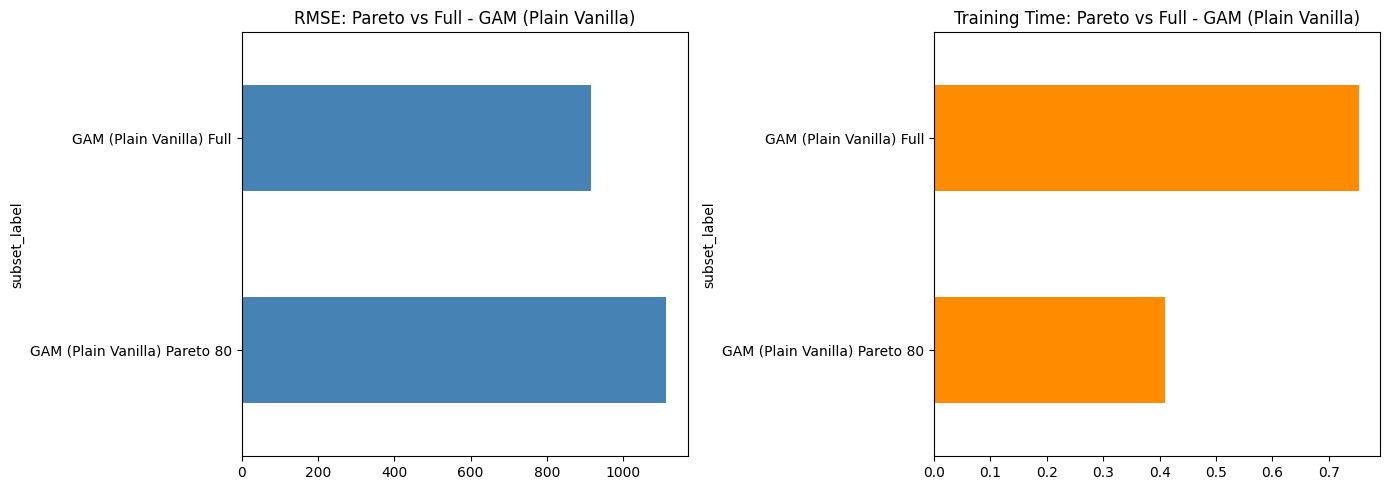

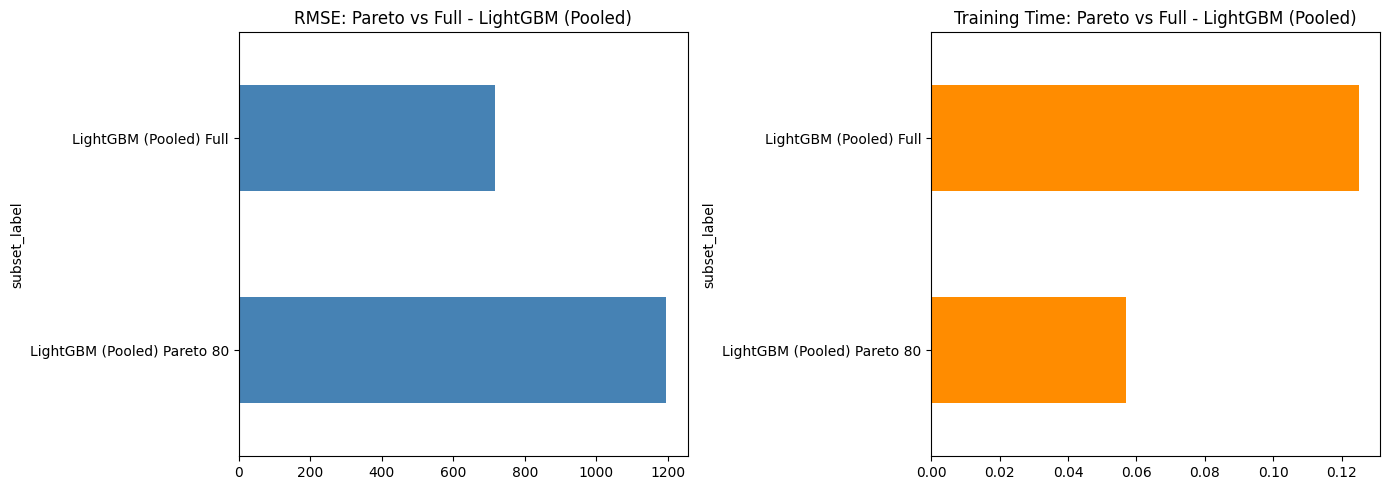

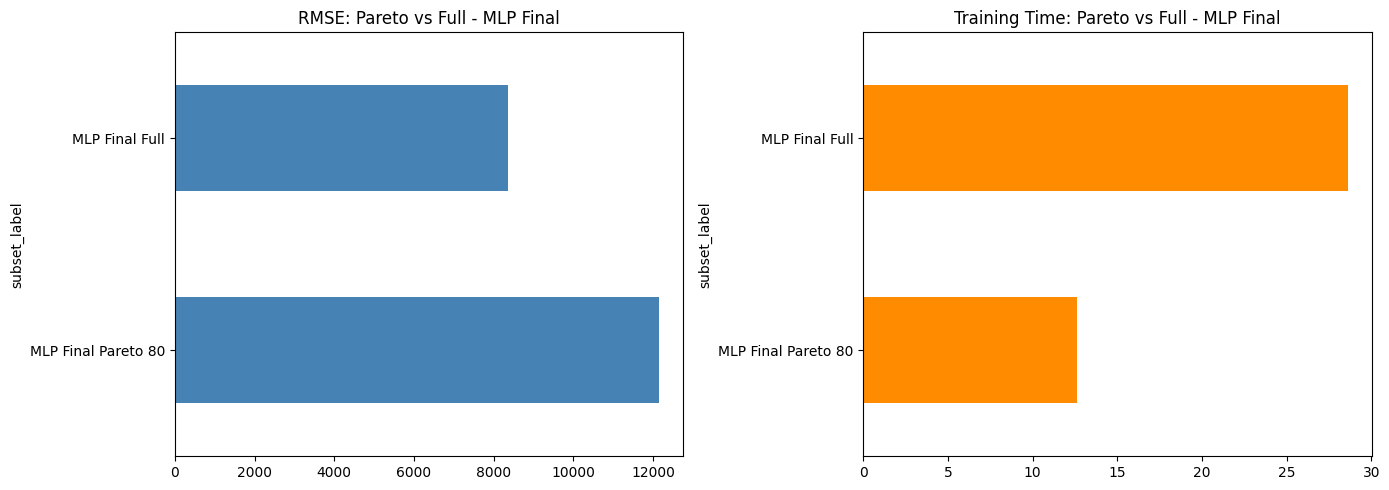

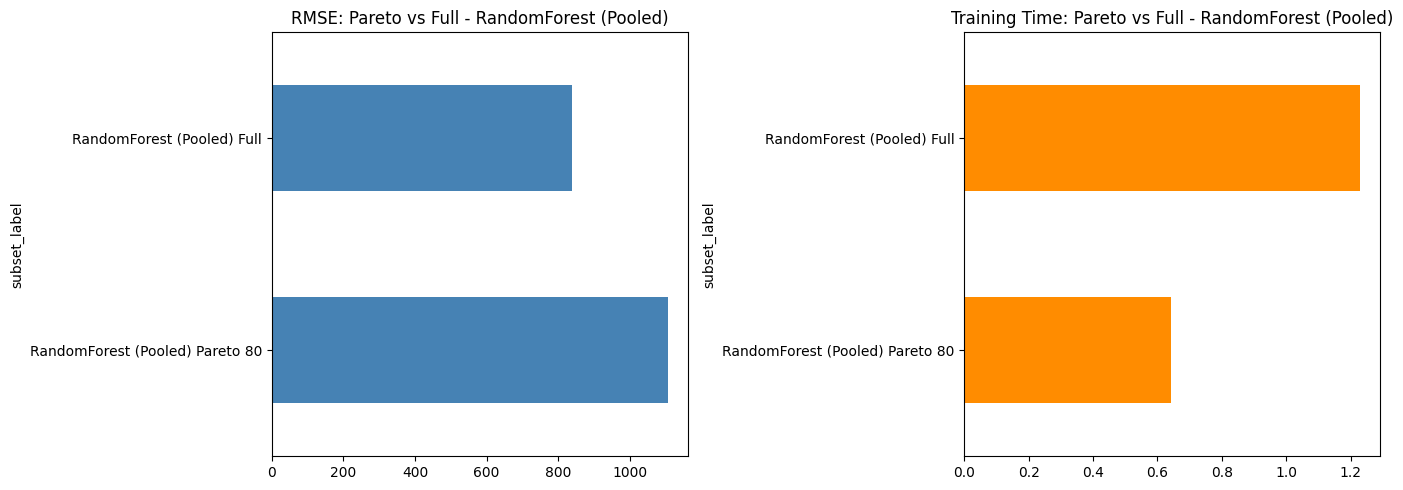

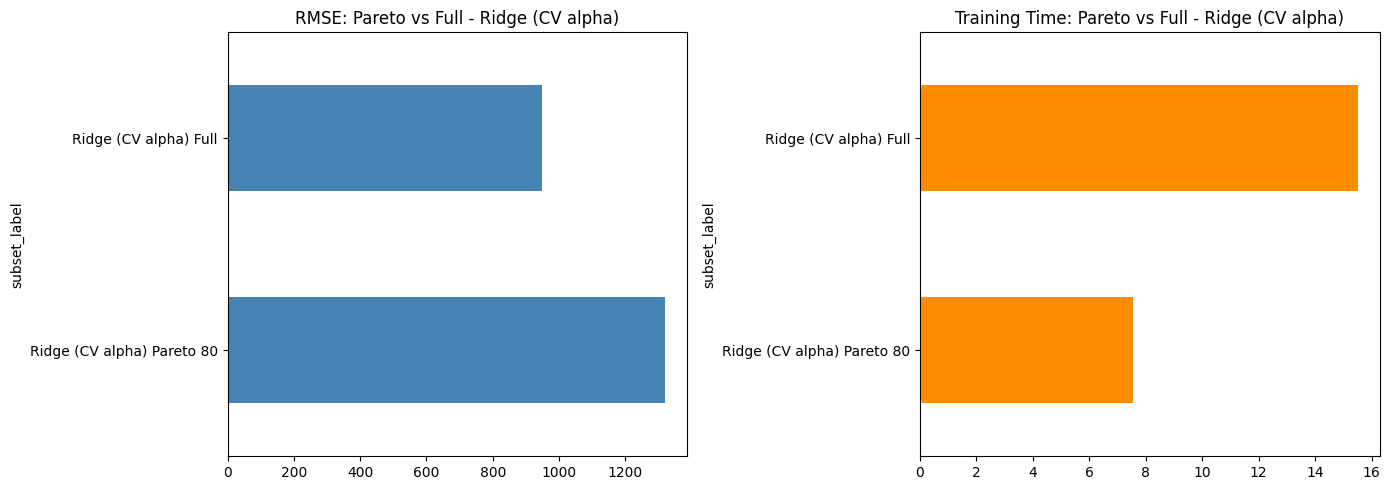

In [12]:
for model_name, group in pareto_df.groupby('model_name'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    group.set_index('subset_label')['RMSE'].plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'RMSE: Pareto vs Full - {model_name}')

    group.set_index('subset_label')['fit_time_total_sec'].plot(kind='barh', ax=axes[1], color='darkorange')
    axes[1].set_title(f'Training Time: Pareto vs Full - {model_name}')

    plt.tight_layout()
    plt.show()


## 7. SHAP Analysis Across Final Models

We compare feature influence across the final saved models using a SHAP method matched to each model family. Random Forest and LightGBM use Tree SHAP, Ridge uses Linear SHAP, and MLP/GAM use a small-sample Kernel SHAP approximation to keep runtime manageable.


In [13]:
def _sample_frame(df, n_rows, random_state=42):
    if len(df) <= n_rows:
        return df.copy()
    return df.sample(n_rows, random_state=random_state).copy()


def _mean_abs_shap_dict(values, feature_names):
    arr = np.asarray(values)
    if arr.ndim == 3:
        arr = arr[0]
    mean_abs = np.abs(arr).mean(axis=0)
    return dict(zip(feature_names, mean_abs))


def _merge_importance_dicts(dicts):
    if not dicts:
        return {}
    all_keys = sorted({k for d in dicts for k in d})
    return {k: float(np.mean([d.get(k, 0.0) for d in dicts])) for k in all_keys}


def pooled_shap_summary(bundle, eval_df, metadata, artifact_key):
    model_type, _, _, model_feature_cols, _ = get_model_spec(metadata, artifact_key)
    X_eval = eval_df[model_feature_cols]
    X_bg = _sample_frame(X_eval, 50)
    X_use = _sample_frame(X_eval, 80)

    if model_type in {'random_forest', 'lightgbm'}:
        explainer = shap.TreeExplainer(bundle)
        shap_values = explainer.shap_values(X_use)
        return _mean_abs_shap_dict(shap_values, model_feature_cols)

    if model_type == 'gam':
        explainer = shap.KernelExplainer(lambda x: bundle.predict(x), X_bg.values)
        shap_values = explainer.shap_values(X_use.values, nsamples=100)
        return _mean_abs_shap_dict(shap_values, model_feature_cols)

    raise ValueError(f'Unsupported pooled SHAP model_type: {model_type}')


def per_combo_shap_summary(bundle, eval_df, metadata, artifact_key):
    model_type, _, _, model_feature_cols, _ = get_model_spec(metadata, artifact_key)
    summaries = []
    for combo_key, obj in bundle.items():
        store, cat = combo_key.split('__', 1)
        ev = eval_df[(eval_df['store_id'] == store) & (eval_df['cat_id'] == cat)]
        if ev.empty:
            continue
        ev_use = _sample_frame(ev, 3)
        bg_use = _sample_frame(ev, min(8, len(ev)))
        scaler = obj['scaler']
        model = obj['model']
        X_eval = scaler.transform(ev_use[model_feature_cols])
        X_bg = scaler.transform(bg_use[model_feature_cols])

        if model_type == 'ridge_cv':
            explainer = shap.LinearExplainer(model, X_bg)
            shap_values = explainer.shap_values(X_eval)
        elif model_type == 'mlp':
            explainer = shap.KernelExplainer(model.predict, X_bg)
            shap_values = explainer.shap_values(X_eval, nsamples=50)
        else:
            raise ValueError(f'Unsupported per-combo SHAP model_type: {model_type}')

        summaries.append(_mean_abs_shap_dict(shap_values, model_feature_cols))

    return _merge_importance_dicts(summaries)


shap_summary_rows = []
shap_top_features = {}
shap_error_rows = []

if shap is None:
    print('shap is not installed in this environment; skipping SHAP comparison.')
    shap_summary_df = pd.DataFrame()
    shap_top_feature_df = pd.DataFrame()
    shap_error_df = pd.DataFrame()
else:
    for artifact_key, entry in supported_artifacts.items():
        meta = entry['metadata']
        bundle = entry['bundle']
        model_name = meta.get('model_name', artifact_key)
        if bundle is None:
            shap_error_rows.append({'artifact_key': artifact_key, 'model_name': model_name, 'reason': 'bundle missing'})
            print(f'Skipping SHAP for {artifact_key}: bundle missing')
            continue
        model_type, model_scope, _, _, _ = get_model_spec(meta, artifact_key)
        try:
            if model_scope == 'pooled':
                summary = pooled_shap_summary(bundle, test, meta, artifact_key)
            else:
                summary = per_combo_shap_summary(bundle, test, meta, artifact_key)

            top_series = pd.Series(summary).sort_values(ascending=False).head(10)
            shap_top_features[model_name] = top_series
            for rank, (feature, value) in enumerate(top_series.items(), start=1):
                shap_summary_rows.append({
                    'artifact_key': artifact_key,
                    'model_name': model_name,
                    'model_type': model_type,
                    'feature_rank': rank,
                    'feature': feature,
                    'mean_abs_shap': float(value)
                })
        except Exception as e:
            shap_error_rows.append({'artifact_key': artifact_key, 'model_name': model_name, 'reason': str(e)})
            print(f'Skipping SHAP for {artifact_key}: {e}')

    shap_summary_df = pd.DataFrame(shap_summary_rows)
    shap_error_df = pd.DataFrame(shap_error_rows)
    shap_top_feature_df = (
        shap_summary_df[shap_summary_df['feature_rank'] <= 5][['model_name', 'feature_rank', 'feature', 'mean_abs_shap']]
        .sort_values(['model_name', 'feature_rank'])
        .reset_index(drop=True)
        if not shap_summary_df.empty else pd.DataFrame()
    )

    if not shap_summary_df.empty:
        n_models = len(shap_top_features)
        fig, axes = plt.subplots(n_models, 1, figsize=(10, 3.6 * n_models))
        axes = np.atleast_1d(axes)
        for ax, (model_name, top_series) in zip(axes, shap_top_features.items()):
            ax.barh(top_series.index[::-1], top_series.values[::-1], color='#4C78A8')
            ax.set_title(f'{model_name}: Top 10 Features by Mean |SHAP|')
            ax.set_xlabel('Mean absolute SHAP value')
        plt.tight_layout()
        plt.show()

shap_top_feature_df


shap is not installed in this environment; skipping SHAP comparison.


""


## 8. Interpretation Notes

Because demand volume differs substantially across store-category combinations, scale-dependent metrics such as RMSE and MAE are driven disproportionately by high-volume series. For that reason, percentage-based metrics are often more informative when comparing model behavior across heterogeneous combinations. In this notebook, RMSE and MAE are still useful because they reflect absolute unit error, but MAPE should be interpreted as the more balanced cross-series comparison metric.


## 9. Streamlining

This notebook is designed to reuse the final saved configurations from each modeling notebook. That means the data sufficiency phase does not need to retune each model from scratch. Instead, it loads the chosen artifact metadata, retrains the same final model specification on reduced subsets, and compares how performance changes as information becomes more limited.


## 10. Comprehensive Findings

This notebook evaluates data sufficiency across the final project models by asking two related questions. First, how much historical training data is needed before each model produces stable and competitive forecasts? Second, does restricting the training set to only the highest-volume store-category combinations preserve most of the useful signal, or does the full dataset still matter? To answer those questions, each final model was retrained on progressively smaller contiguous windows of the training history at 25%, 50%, 75%, and 100% of the available training data, with the same validation block held fixed for comparison. A separate Pareto experiment then compared training on the full dataset against training only on the highest-volume combinations.

The saved-model comparison shows a clear overall ranking. Ridge produced the strongest held-out performance, with LightGBM and Random Forest close behind. GAM remained reasonably accurate but weaker than the leading tabular models, while the MLP was substantially worse than all other approaches. Because the store-category series differ greatly in scale, these results are best interpreted using both scale-dependent and percentage-based metrics: RMSE and MAE capture large unit errors, while MAPE gives a more balanced view across high- and low-volume combinations.

| Model | RMSE | MAPE | R² |
| --- | ---: | ---: | ---: |
| Ridge | 756 | 4.2% | 0.9913 |
| LightGBM | 771 | 4.4% | 0.9909 |
| Random Forest | 807 | 4.4% | 0.9900 |
| GAM | 957 | 7.3% | 0.9860 |
| MLP | 8827 | 32.0% | -0.1916 |

The reduced-data experiments show that LightGBM is the most data-efficient and stable model. Its RMSE improves consistently as more training history is added, and its variance across repeated contiguous subsets remains relatively small. Random Forest shows a similar pattern but is modestly weaker at every fraction. Ridge is more sensitive to limited data, performing poorly at 25% of the training history but improving sharply as additional history becomes available, which suggests that it benefits strongly from more temporal coverage. GAM shows moderate full-data performance but noticeably unstable behavior under reduced subsets, indicating that its fit is more sensitive to which historical window is available. The MLP remains uncompetitive across all fractions and does not show evidence that simply adding more data within this range is enough to make it competitive.

| Model | RMSE at 25% | RMSE at 50% | RMSE at 75% | RMSE at 100% |
| --- | ---: | ---: | ---: | ---: |
| LightGBM | 1093 | 900 | 806 | 716 |
| Random Forest | 1055 | 937 | 876 | 839 |
| Ridge | 2675 | 1602 | 1243 | 949 |
| GAM | 1942 | 5139 | 1803 | 917 |
| MLP | 8585 | 7936 | 7897 | 8349 |

The Pareto experiment provides a different perspective on data sufficiency. Rather than asking how much history is needed, it asks whether a concentrated subset of the highest-volume store-category combinations contains enough information to substitute for the full dataset. The answer is mostly no. For LightGBM and Random Forest, performance worsens substantially when training is restricted to the Pareto subset, suggesting that lower-volume combinations still provide important structural information. GAM also declines under Pareto-only training. Ridge is the only partial exception: its RMSE worsens, but its MAPE remains relatively stable, which suggests it is somewhat more robust to concentration when performance is viewed in percentage terms. The MLP becomes even worse under the Pareto subset, reinforcing the conclusion that it is not well suited to this forecasting task in its current form.

| Model | Full RMSE | Pareto RMSE | Full MAPE | Pareto MAPE |
| --- | ---: | ---: | ---: | ---: |
| LightGBM | 716 | 1195 | 4.5% | 25.4% |
| Random Forest | 839 | 1106 | 5.0% | 20.3% |
| Ridge | 949 | 1321 | 5.3% | 5.0% |
| GAM | 917 | 1113 | 14.6% | 16.5% |
| MLP | 8349 | 12153 | 34.3% | 51.2% |

Taken together, these experiments support three main conclusions. First, LightGBM offers the strongest balance of accuracy, stability, and computational efficiency when data availability is reduced. Second, Ridge becomes highly competitive once enough training history is available, even though it is more sensitive in low-data settings. Third, retaining the full distribution of store-category combinations is more useful than restricting training to only the highest-volume subset, which implies that lower-volume combinations still contribute meaningful predictive structure. Overall, the data sufficiency results reinforce the broader project finding that well-tuned tabular models outperform the neural network baseline on this forecasting problem and that additional model complexity does not automatically lead to better results.
